# Statistical Analysis of Pupil Data

```{admonition} Overview
PupEyes is designed for **preprocessing**, namely preparing your pupil data in an analysis-friendly format so you can perform whatever analyses that you deem appropriate for your research goals. Indeed, there are [many ways to analyze pupil size data](https://link.springer.com/book/10.1007/978-3-031-54896-3), and it would be impractical to implement them all. This tutorial seeks to demonstrate how easily you can conduct analyses with preprocessed `PupEyes` data.

We'll cover two basic approaches to analyzing task-evoked pupillary responses:

1. **Using a Predefined Time Window**

2. **Plotting Evoked Responses**

3. **Cluster-based Permutation Testing**

```

```{note} 
Some analyses in this tutorial require the `mne` package, a Python library for visualizing and analyzing neurophysiological data. `mne` is not included as a dependency for PupEyes. For information on how to install, see: https://mne.tools/stable/install/index.html
```

## Load Data

We will load our preprocessed data from the [Pupil Preprocessing](pupil_preproc.ipynb) tutorial.

In [1]:
import pandas as pd
import pupeyes as pe

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
# use .load() to load the .pkl file
p = pe.PupilProcessor.load('example_data/myproject.pkl')
# show preview
p.final_data.head(5)

,participant,block,trial,event,trialtime,x,y,pp_final,eventtime,group
0,sub004,A,1,stimulus,983,867.3,572.7,-51.159402,0,B
1,sub004,A,1,stimulus,984,867.8,570.9,-51.729276,1,B
2,sub004,A,1,stimulus,985,868.2,569.1,-52.289048,2,B
3,sub004,A,1,stimulus,986,868.3,568.8,-52.839291,3,B
4,sub004,A,1,stimulus,987,867.7,569.7,-53.380616,4,B


## Use a Predefined Time Window

If you have a hypothesis for when your task-evoked pupillary response will emerge, you can simply select that time window and compute the mean pupil size within that window.

For example, if we hypothesize that the effect emerges during 600 ms to 1000 ms after stimulus onset:

In [40]:
p.after600 = p.final_data.query('eventtime > 600 & eventtime < 1000').groupby(['group','participant','block','trial']).pp_final.mean() 
p.after600

group  participant  block  trial
A      sub001       A      1        365.167948
                           2        270.234047
                           4        106.886913
                           5        -57.519795
                           7         48.590191
                           9       -108.547532
                           10       107.700489
       sub002       A      2         -55.69361
                           3       -149.191105
                           4        148.102853
                           5        386.277495
                           6        173.346839
                           7        250.670634
                           8        255.979445
                           9          4.996557
                           10       -97.274271
B      sub003       A      1        -61.174798
                           2       -158.265573
                           3        -185.21927
                           4       -389.467999
                           

From now on, mean pupil sizes can be analyzed in the same way as response times (RTs).

## Plot Evoked Response

Oftentimes we do not have a hypothesis about when an effect should emerge. Even if we do, it is always nice to have a plot showing the entire evoked response. PupEyes has a built-in method, `.plot_evoked()`, to plot evoked responses. 

Data will be padded to minimum length: 2997 samples
Condition {'group': 'B'}: Computing average from 19 trials
Condition {'group': 'A'}: Computing average from 16 trials


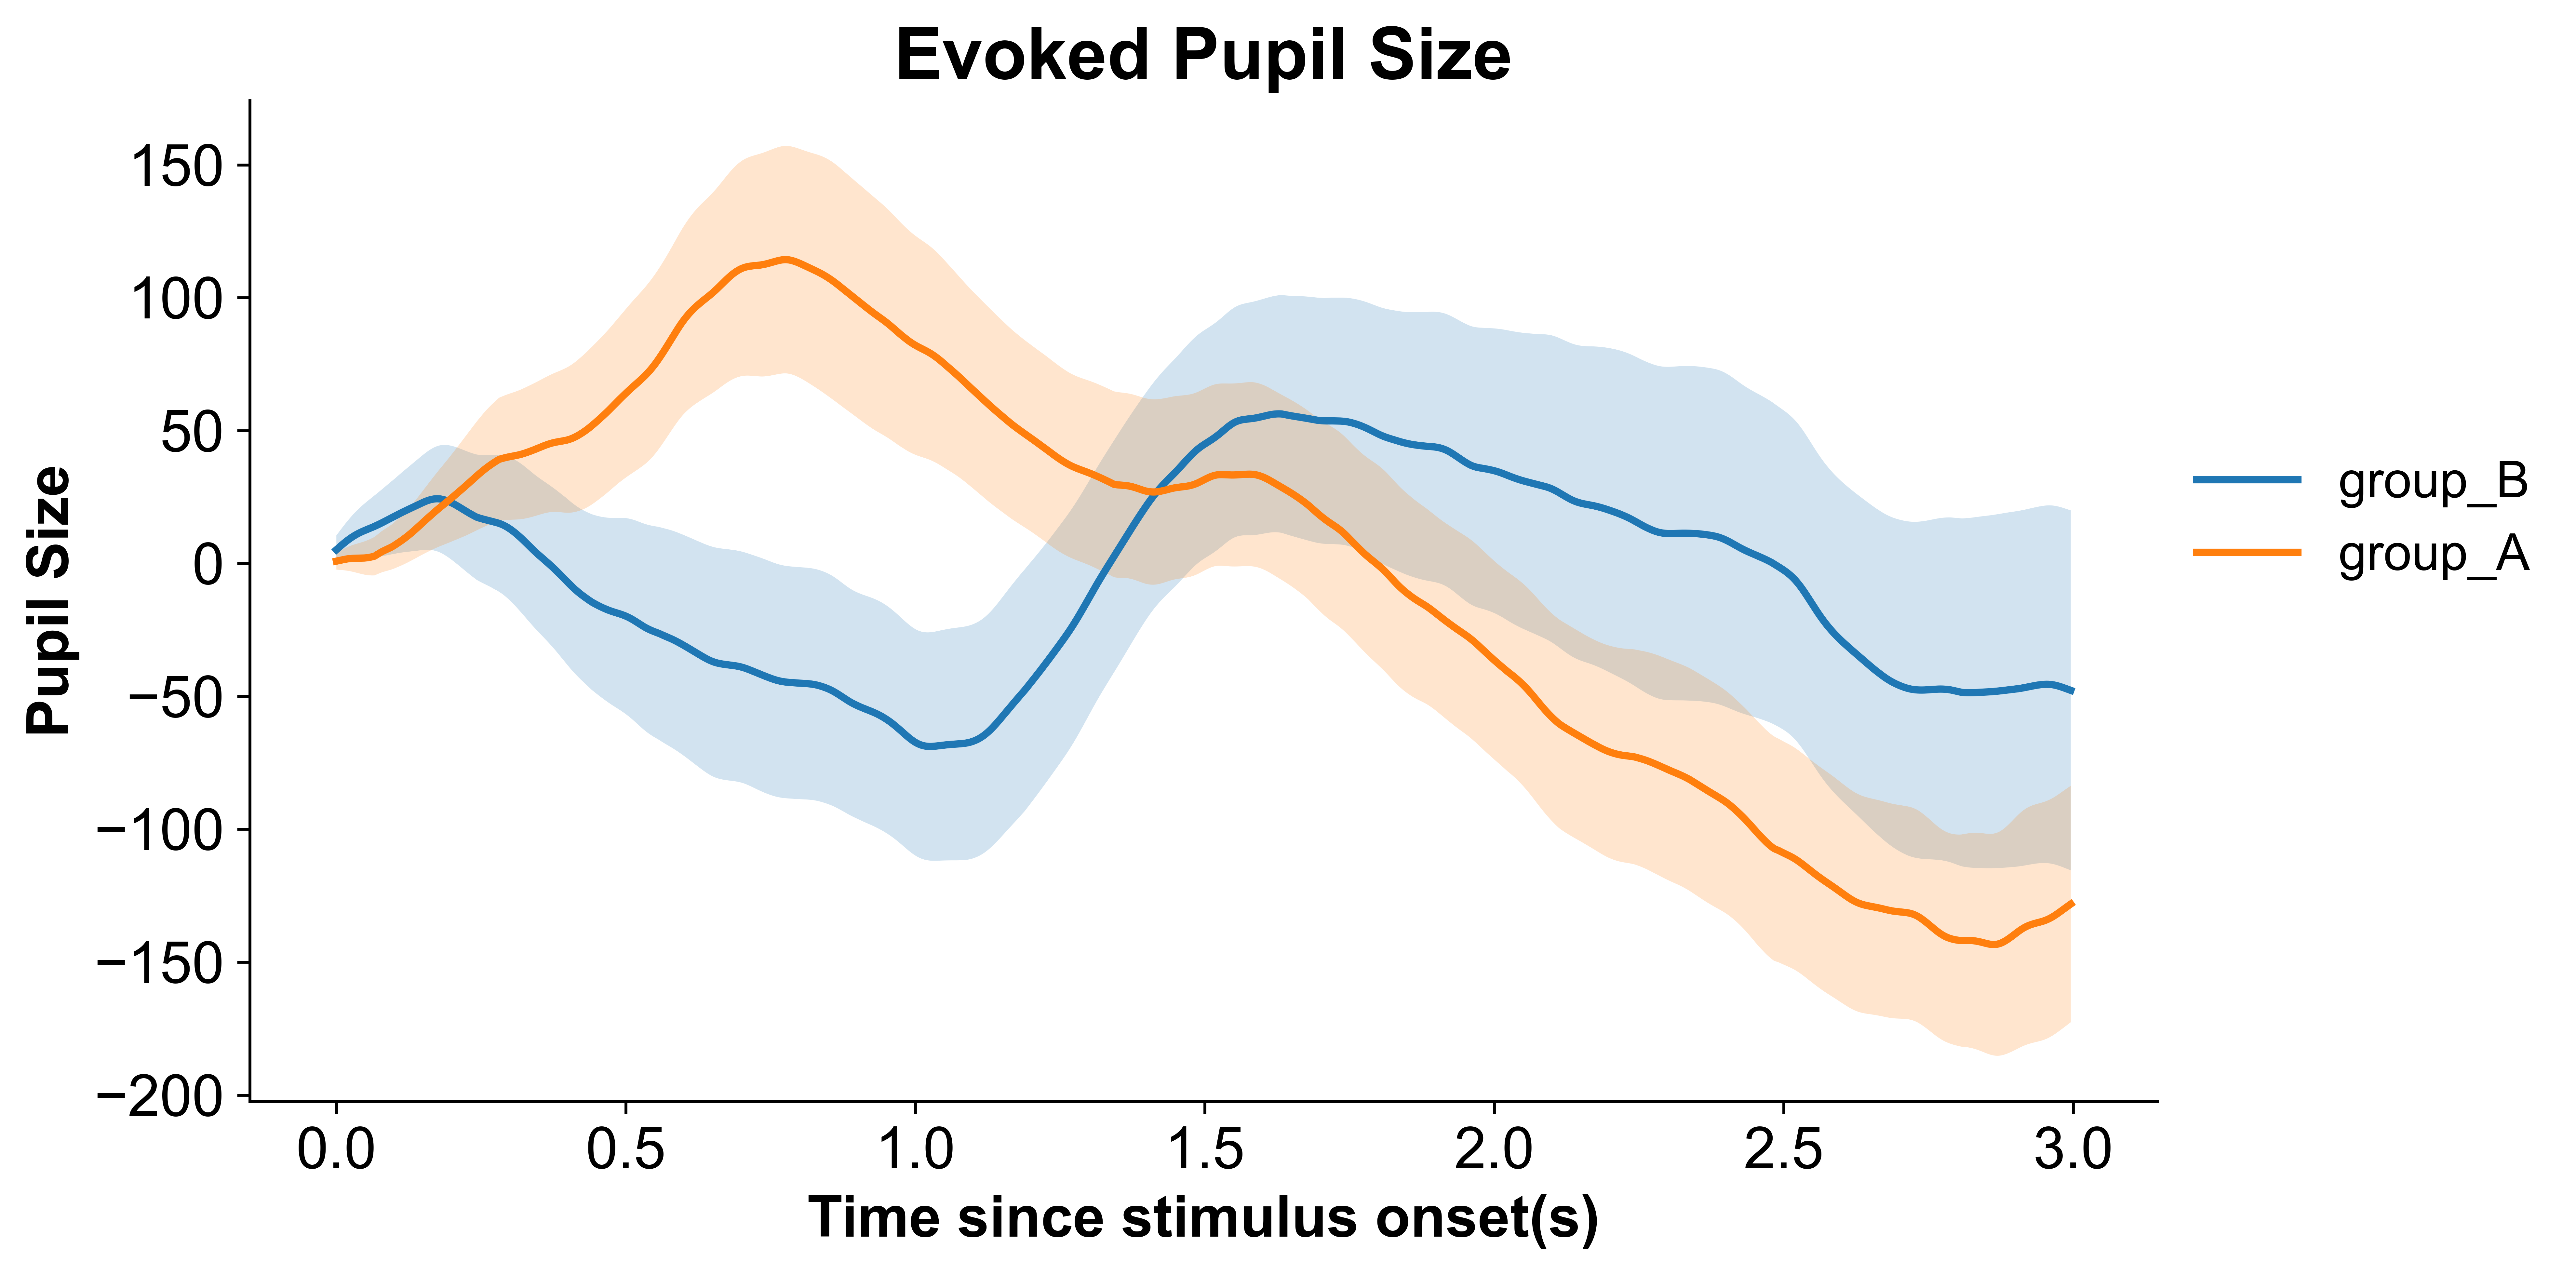

In [41]:
test_array, (fig, ax) = p.plot_evoked(data='final_data', 
                                      condition='group',
                                      pupil_col='pp_final', 
                                      error='sem')

The evoked responses in the plot above are grand averages (mean across trials). If you want to plot evoked responses at the participant level, you can aggregate the data by participant:

Data will be padded to minimum length: 2997 samples
Condition {'group': 'B'}: Computing average from 2 ['participant'] means
Condition {'group': 'A'}: Computing average from 2 ['participant'] means


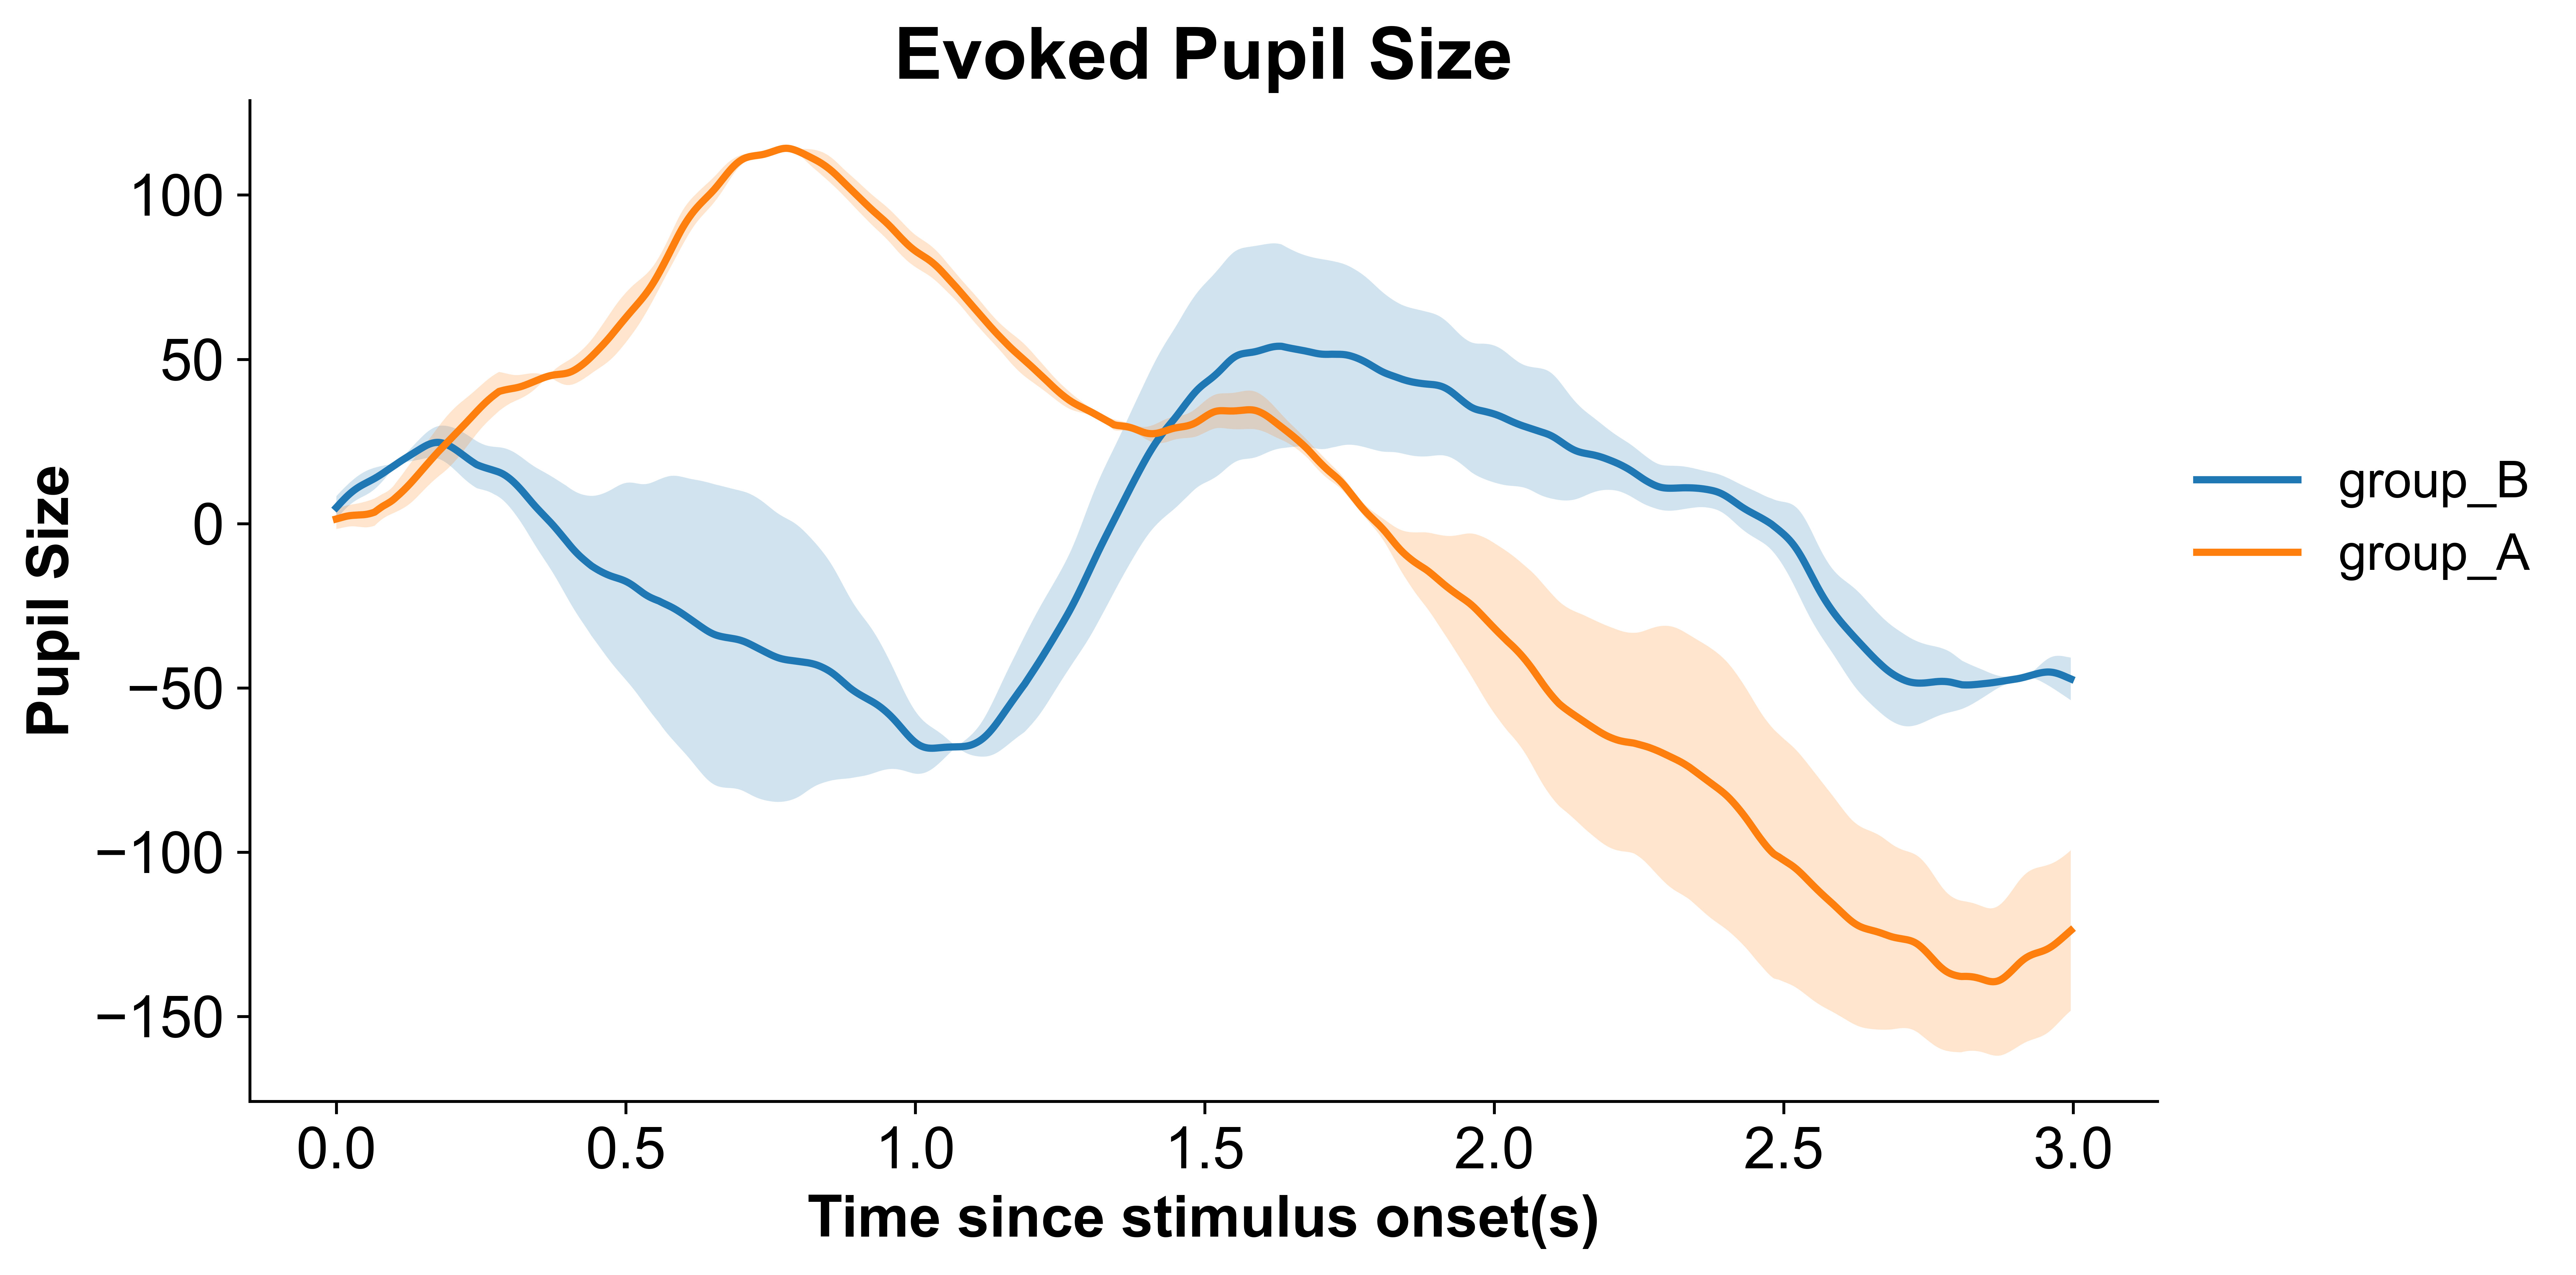

In [60]:
test_array, (fig, ax) = p.plot_evoked(data='final_data', 
                                      agg_by='participant', # aggregate by participant
                                      condition='group', 
                                      pupil_col='pp_final', 
                                      error='sem')

`.plot_evoked()` also returns the data being plotted, which can be useful for subsequent statistical tests. Here, the data for group A is an array with a shape of 2 * 2997: 2 participants since we aggregated the data, and 2997 data points for each participant.

In [49]:
test_array['group_A'].shape

(2, 2997)

## Cluster-based Permutation Testing

In [52]:
import mne.stats as ms

Data will be padded to minimum length: 2997 samples
Condition {'group': 'B'}: Computing average from 19 trials
Condition {'group': 'A'}: Computing average from 16 trials


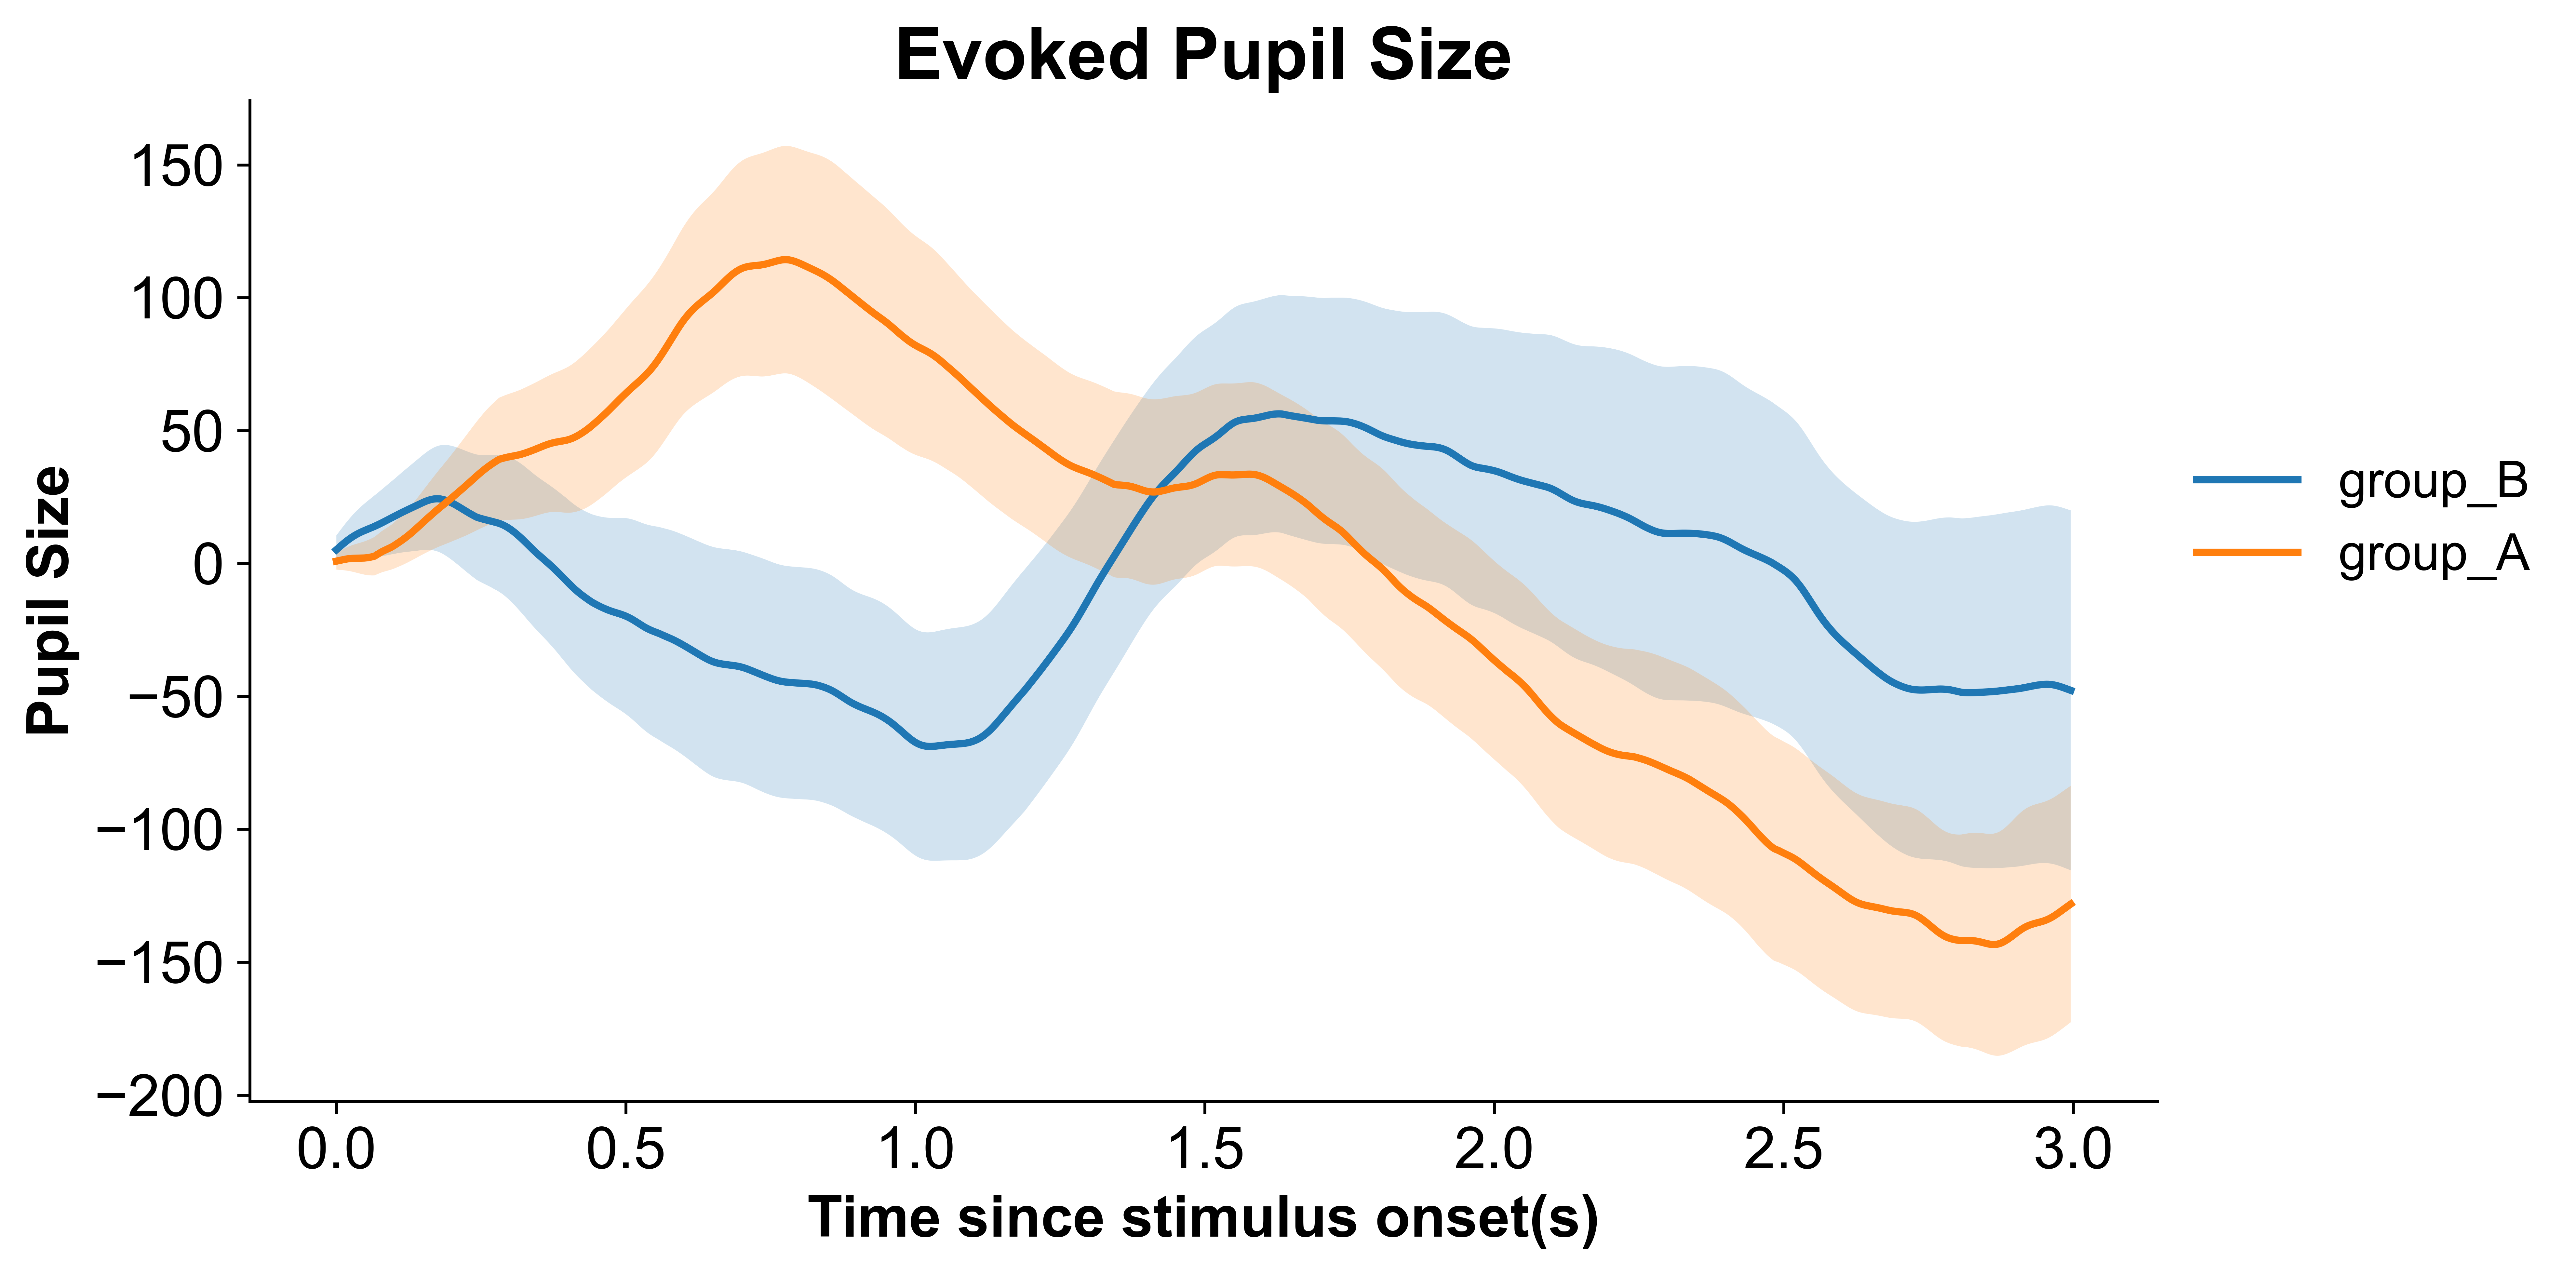

In [74]:
test_array, (fig, ax) = p.plot_evoked(data='final_data', 
                                      condition='group',
                                      pupil_col='pp_final', 
                                      error='sem')

In [75]:
T_obs, clusters, cluster_p_values, H0 = ms.permutation_cluster_1samp_test(
    test_array['group_A'],
    n_permutations=1000,
    tail=0,
    n_jobs=-1,
    out_type="mask",
)

Using a threshold of 2.131450
stat_fun(H1): min=-3.457604708253508 max=2.6628620122471807
Running initial clustering …
Found 2 clusters


100%|██████████| Permuting : 999/999 [00:00<00:00, 3489.24it/s]


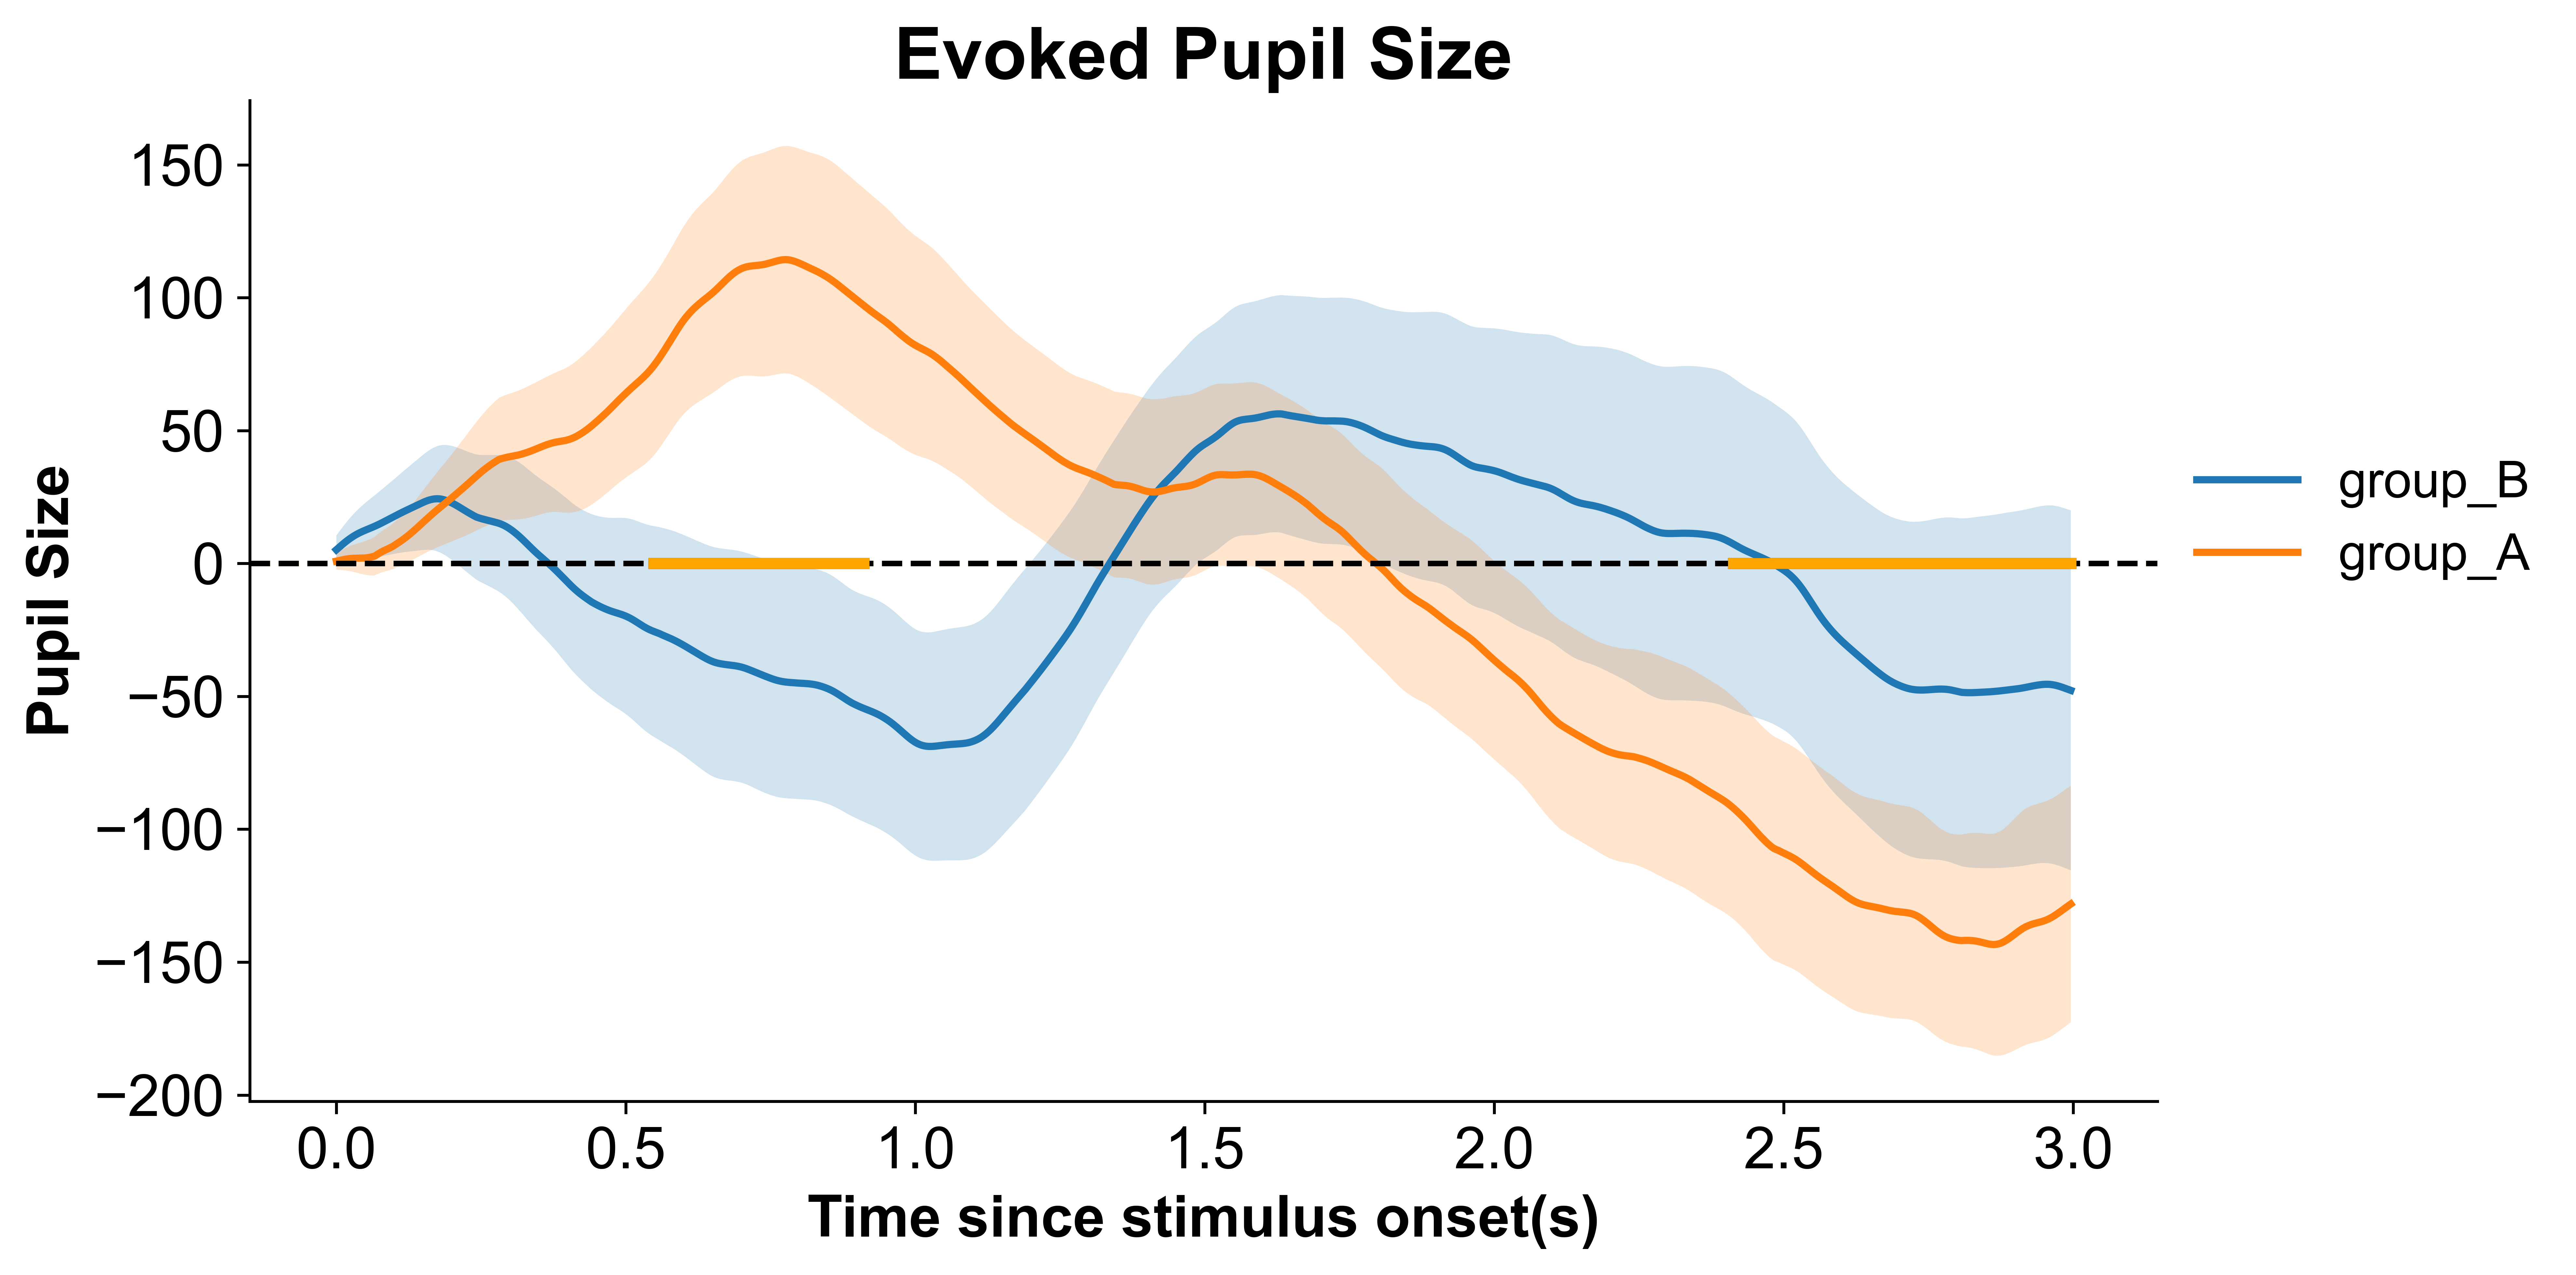

In [80]:
import matplotlib.pyplot as plt
import numpy as np

# baseline
ax.axhline(0, color='black', linestyle='--')

# plot clusters
t = np.arange(test_array['group_A'].shape[1]) / 1000
for cluster in clusters:
    #ax.fill_between(t[cluster], ci_low[cluster], ci_high[cluster], alpha=0.2)
    ax.plot(t[cluster], 0*np.ones(len(t[cluster])), color='orange', linewidth=3)
fig